# Lecture 2: Data processing in Pandas library

[Data Visualization · 1-DAV-105](https://fmfi-compbio.github.io/viz/)

Lecture by Broňa Brejová

## Tabular data

* We will often work with data in the form of tables.
* Columns represent different features / variables (príznaky, atribúty, veličiny, premenné).
* Rows represent different items / data points / observations (countries, people, dates of measurement, ...).
* A small example:

| Country | Region	| Population	| Area (km<sup>2</sup>) | Landlocked |
|--|--|--|--|--|
| Slovakia	| Europe  |  5458827 |  49030 | yes |
| Ukraine   | Europe  | 44132050 | 603550 |  no |
| Poland	| Europe  | 37899071 | 312710 |  no |
| Czech Republic | Europe | 10697858 | 78871 | yes |
| Austria   | Europe  |  8916864 |  83879 | yes |
| Hungary	| Europe  |  9750148 |  93030 | yes |


## Pandas library

* [Pandas](https://pandas.pydata.org/) is a Python library for data manipulation and analysis.
* It is fast and has many functions for data import and export in various formats.
* [Documentation](https://pandas.pydata.org/pandas-docs/stable/), [overview](https://pandas.pydata.org/pandas-docs/stable/getting_started/overview.html#overview), [tutorial](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html)
* Beware: currently transitioning to version 3.0, but Colab still uses 2.2, so we will use 2.2.


Basic data structures 

* `Series`: 1D table, all elements of the same type. 
* `DataFrame`: 2D table, elements within each column of the same type.

**NumPy library**

* [NumPy](https://numpy.org/) is a library of efficient multi-dimensional arrays used for numerical computations.
* We will mostly use Pandas, but some NumPy functions will be useful.
* [Tutorial](https://numpy.org/devdocs/user/quickstart.html), [reference](https://numpy.org/devdocs/reference/index.html)


In [1]:
import numpy as np
import pandas as pd
from IPython.display import Markdown 
import matplotlib.pyplot as plt

/tmp/ipykernel_100376/959967481.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Creating Series and DataFrames

* Bellow we show two manual ways of creating a `DataFrame` containing the small table of countries above.
* The first way gets a `Series` for each column, the second way gets a dictionary (or a tuple) for each row.
* We will usually read tabular data from files, see an example in the second half this lecture.

In [2]:
# create Series for each column
countries = pd.Series(['Slovakia', 'Ukraine', 'Poland', 'Czech Republic', 'Austria', 'Hungary'])
regions = pd.Series(['Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe'])
populations = pd.Series([5458827, 44132050, 37899071, 10697858, 8916864, 9750148])
areas = pd.Series([49030, 603550, 312710, 78871, 83879, 93030])
landlocked = pd.Series([True, False, False, True, True, True])
# combine columns into a DataFrame
table = pd.DataFrame({'country':countries,
                    'region':regions, 
                    'population':populations, 
                    'area':areas,
                    'landlocked':landlocked})
# display: special notebook command for pretty-printing data
display(table)

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True
4,Austria,Europe,8916864,83879,True
5,Hungary,Europe,9750148,93030,True


In [3]:
list_of_dicts = [
    {'country':'Slovakia', 'region':'Europe', 'population':5458827, 'area':49030, 'landlocked':True},
    {'country':'Ukraine', 'region':'Europe', 'population':44132050, 'area':603550, 'landlocked':False},
    {'country':'Poland', 'region':'Europe', 'population':37899071, 'area':312710, 'landlocked':False},
    {'country':'Czech Republic', 'region':'Europe', 'population':10697858, 'area':78871, 'landlocked':True},
]
table_from_list = pd.DataFrame.from_records(list_of_dicts)
display(table_from_list)

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True


### Accessing elements of Series and DataFrame by position

* Attribute `ndim` is the number of dimensions. E.g. `areas.ndim` is `1`, `table.ndim` is `2`.
* Attribute `shape` is a tuple holding the size in each dimension. E.g. `areas.shape` is `(6,)`, `table.shape` is `(6,5)`.
* Rows and columns are numbered 0, 1, ...
* To access a particular column / row, use `some_series.`[`iloc`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.iloc.html)`[row]` or `some_table.`[`iloc`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html)`[row, column]`.
* Rows and columns in `iloc` can be 
    * a single number e.g. `0`, 
    * a slice (range) e.g. `0:2` or `:` for everything, 
    * a list of positions e.g. `[0, 2, 3]` 
    * a list of boolean values `[True, False, True, True]`.
* The result is a single element or a Series / DataFrame of a smaller size.


In [4]:
display(Markdown("**table:**"), table)
display(Markdown("**table.iloc[1, 2]:**"), table.iloc[1, 2])
display(Markdown("**table.iloc[[0, 2, 3], 0:2]**"), table.iloc[[0, 2, 3],  0:2])
display(Markdown("**table.iloc[[True, False, True, True, False, False], :]**"), 
        table.iloc[[True, False, True, True, False, False], :])


**table:**

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True
4,Austria,Europe,8916864,83879,True
5,Hungary,Europe,9750148,93030,True


**table.iloc[1, 2]:**

44132050

**table.iloc[[0, 2, 3], 0:2]**

,country,region
0,Slovakia,Europe
2,Poland,Europe
3,Czech Republic,Europe


**table.iloc[[True, False, True, True, False, False], :]**

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True


### Views vs. copies

* Accessing parts of tables by `iloc` may return a "view" sharing the underlying data with the original table.
* If we later modify this result, it is not clear if the original table is modified.
  * Since pandas 3.0, it is guaranteed that the original table is not modified, but in pandas 2.2 we get a warning.
* Direct assignment of new values to a part of the table works: `some_table.iloc[row, column] = new_value` modifies `some_table`.
* To copy a table, use `other_table = some_table.copy()`. 

In [5]:
table2 = table.copy()
# create a copy of the original table

table2.iloc[0,0] = 'Slovensko'
display(Markdown("**`table2` with Slovakia renamed to Slovensko:**"),table2)
# table2 now has Slovensko instead of Slovakia

countries2 = table2.iloc[: , 0]
# countries2 is now a view or a copy of one column of table2
display(Markdown("...modifying `countries2`"))
countries2.iloc[5] = 'Maďarsko'
display(Markdown("**`countries2` with Hungary renamed to Maďarsko:**"),countries2)
display(Markdown("**`table2` after `countries2` is modified:**"),table2)
# we get a warning in pandas 2.2, but in pandas 3.0 it is guaranteed that table2 is not modified

**`table2` with Slovakia renamed to Slovensko:**

,country,region,population,area,landlocked
0,Slovensko,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True
4,Austria,Europe,8916864,83879,True
5,Hungary,Europe,9750148,93030,True


...modifying `countries2`

/tmp/ipykernel_100376/3219913519.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries2.iloc[5] = 'Maďarsko'


**`countries2` with Hungary renamed to Maďarsko:**

0         Slovensko
1           Ukraine
2            Poland
3    Czech Republic
4           Austria
5          Maďarsko
Name: country, dtype: object

**`table2` after `countries2` is modified:**

,country,region,population,area,landlocked
0,Slovensko,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True
4,Austria,Europe,8916864,83879,True
5,Maďarsko,Europe,9750148,93030,True


### Inplace operations

* Many operations return a new table.
* If you do not need the original table, you can specify option `inplace=True`.
* The example below sorts a table by a specified column, returning a new table or replacing the old one.

In [6]:
# copy original table to table2
table2 = table.copy()

# table3 is a copy of table2 sorted by population size
table3 = table2.sort_values(by="population")

# display both table2 and table3
display(Markdown("**Original table2:**"), table2)
display(Markdown("**Sorted table3:**"), table3)

# now change table2 to be sorted by name of the country
table2.sort_values(by="country", inplace=True)
display(Markdown("**Sorted table2:**"), table2)

**Original table2:**

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True
4,Austria,Europe,8916864,83879,True
5,Hungary,Europe,9750148,93030,True


**Sorted table3:**

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
4,Austria,Europe,8916864,83879,True
5,Hungary,Europe,9750148,93030,True
3,Czech Republic,Europe,10697858,78871,True
2,Poland,Europe,37899071,312710,False
1,Ukraine,Europe,44132050,603550,False


**Sorted table2:**

,country,region,population,area,landlocked
4,Austria,Europe,8916864,83879,True
3,Czech Republic,Europe,10697858,78871,True
5,Hungary,Europe,9750148,93030,True
2,Poland,Europe,37899071,312710,False
0,Slovakia,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False


### Indexes

* Rows and columns have both an integer location (0,1,2,...)  and an index (name).
* In our table, column names are `'country'`, `'region'` etc.
* We have not named rows, so a default location-based index was constructed.
    * See the sorted tables above—their index labels are kept from the original.
* Indexes can be obtained by attributes `index` and `columns`.
* Index can be more complex (multiindex), we will see later.

In [7]:
display(Markdown("**`table.columns` is an object of class `Index`:**"), 
        table.columns)
display(Markdown("**`table.columns.values` is an array of column names:**"), 
        table.columns.values)

display(Markdown("**`table.index.values` is an array of row names, "
                 + "here equal to location:**"),
        table.index.values)
display(Markdown("**index for a `Series`: `areas.index.values`:**"), 
        areas.index.values)

**`table.columns` is an object of class `Index`:**

Index(['country', 'region', 'population', 'area', 'landlocked'], dtype='object')

**`table.columns.values` is an array of column names:**

array(['country', 'region', 'population', 'area', 'landlocked'],
      dtype=object)

**`table.index.values` is an array of row names, here equal to location:**

array([0, 1, 2, 3, 4, 5])

**index for a `Series`: `areas.index.values`:**

array([0, 1, 2, 3, 4, 5])

#### Changing indexes

* We can set the country name as an index using [`set_index`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.set_index.html), the opposite is [`reset_index`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.reset_index.html) 
* In Series, use [`set_axis`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.set_axis.html) and [`reset_index`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.reset_index.html).


In [8]:
display(Markdown("**table after setting country name as index:**"))
table2 = table.set_index('country')
display(table2)

display(Markdown("**`reset_index` will put the index back as a column:**"))
table3 = table2.reset_index()
display(table3)

**table after setting country name as index:**

,region,population,area,landlocked
country,,,,
Slovakia,Europe,5458827,49030,True
Ukraine,Europe,44132050,603550,False
Poland,Europe,37899071,312710,False
Czech Republic,Europe,10697858,78871,True
Austria,Europe,8916864,83879,True
Hungary,Europe,9750148,93030,True


**`reset_index` will put the index back as a column:**

,country,region,population,area,landlocked
0,Slovakia,Europe,5458827,49030,True
1,Ukraine,Europe,44132050,603550,False
2,Poland,Europe,37899071,312710,False
3,Czech Republic,Europe,10697858,78871,True
4,Austria,Europe,8916864,83879,True
5,Hungary,Europe,9750148,93030,True


### Accessing elements by index

* Method `some_table.loc[row, column]` is an analog of `iloc`, but using indexes rather than locations.
* You can use just `[]` instead of `loc`, but this is sometimes ambiguous whether you mean `iloc` or `loc`.
* Some examples for `Series`:

In [9]:
populations2 = populations.set_axis(countries)
display(Markdown("**`populations2` Series with index:**"), populations2)
display(Markdown("**`populations2.loc['Slovakia']`**:"), 
        populations2.loc['Slovakia'])
display(Markdown("**`populations2.loc[['Slovakia','Poland']]`**:"), 
        populations2.loc[['Slovakia','Poland']])

display(Markdown("**`populations2['Czech Republic']`**:"),
        populations2['Czech Republic'])

**`populations2` Series with index:**

Slovakia           5458827
Ukraine           44132050
Poland            37899071
Czech Republic    10697858
Austria            8916864
Hungary            9750148
dtype: int64

**`populations2.loc['Slovakia']`**:

5458827

**`populations2.loc[['Slovakia','Poland']]`**:

Slovakia     5458827
Poland      37899071
dtype: int64

**`populations2['Czech Republic']`**:

10697858

### Operations and functions on Series

* Operations such as `+`, `*` can be applied on two Series, causing them to be used on each corresponding pair of elements. 
* For example, `populations / areas` will compute population density for each country.
* You can also use a single number (scalar) as an operand, e.g. `populations / 1e6` will get population in millions.
* NumPy also contains functions that can be applied to each element of a series, e.g. `np.log(populations)`.
* Relational operators such as `populations < 10e6` produce Series of boolean values.
    * Those can be then used in `loc`, `[]`.

In [10]:
# creating two Series with country as index
populations2 = populations.set_axis(countries)
areas2 = areas.set_axis(countries)
display(Markdown("**`populations2 / areas2`:**"), populations2 / areas2)
display(Markdown("**`populations2 / 1e6`:**"), populations2 / 1e6)
display(Markdown("**`populations2 > 10e6`:**"), populations2 > 10e6)
display(Markdown("**`areas2[populations2 > 10e6]`:**"), 
        areas2.loc[populations2 > 10e6])
display(Markdown("**`np.log10(populations2)`:**"), np.log10(populations2))

**`populations2 / areas2`:**

Slovakia          111.336467
Ukraine            73.120785
Poland            121.195584
Czech Republic    135.637408
Austria           106.306275
Hungary           104.806493
dtype: float64

**`populations2 / 1e6`:**

Slovakia           5.458827
Ukraine           44.132050
Poland            37.899071
Czech Republic    10.697858
Austria            8.916864
Hungary            9.750148
dtype: float64

**`populations2 > 10e6`:**

Slovakia          False
Ukraine            True
Poland             True
Czech Republic     True
Austria           False
Hungary           False
dtype: bool

**`areas2[populations2 > 10e6]`:**

Ukraine           603550
Poland            312710
Czech Republic     78871
dtype: int64

**`np.log10(populations2)`:**

Slovakia          6.737099
Ukraine           7.644754
Poland            7.578629
Czech Republic    7.029297
Austria           6.950212
Hungary           6.989011
dtype: float64

**Beware:** when we combine two Series, e.g. by +, Pandas will use index, not position, to pair up elements. 

In [11]:
a = pd.Series([1, 2, 3, 4], index=['a', 'b', 'c', 'd'])
b = pd.Series([10, 20, 30], index=['c', 'a', 'e'])
c = pd.Series([100, 200])
display(Markdown("**Series a:**"), a)
display(Markdown("**Series b:**"), b)
display(Markdown("**Series c:**"), c)
display(Markdown("**Series a+b:**"), a + b)
display(Markdown("**Series a+c:**"), a + c)

**Series a:**

a    1
b    2
c    3
d    4
dtype: int64

**Series b:**

c    10
a    20
e    30
dtype: int64

**Series c:**

0    100
1    200
dtype: int64

**Series a+b:**

a    21.0
b     NaN
c    13.0
d     NaN
e     NaN
dtype: float64

**Series a+c:**

a   NaN
b   NaN
c   NaN
d   NaN
0   NaN
1   NaN
dtype: float64

### Working with DataFrame columns

* `DataFrame` is similar to a dictionary of `Series` objects (columns).
* For example, `table['area']` or `table.area` is the **column** of country areas.
* New columns can be added to a DataFrame: `table['density'] = table['population'] / table['area']`
* By `table[table['population'] > 1e7]` we get countries with more that 10 million people (CZ, PL).

In [12]:
display(Markdown("**`table['area']`:**"), table['area'])
display(Markdown("**`table.area`:**"), table.area)
display(Markdown("**Adding density:**"))
display(Markdown("`table['density'] = table['population'] / table['area']`"))
table['density'] = table['population'] / table['area']
display(Markdown("**`table[table['population'] > 1e7]`:**"), 
        table[table['population'] > 1e7])

**`table['area']`:**

0     49030
1    603550
2    312710
3     78871
4     83879
5     93030
Name: area, dtype: int64

**`table.area`:**

0     49030
1    603550
2    312710
3     78871
4     83879
5     93030
Name: area, dtype: int64

**Adding density:**

`table['density'] = table['population'] / table['area']`

**`table[table['population'] > 1e7]`:**

,country,region,population,area,landlocked,density
1,Ukraine,Europe,44132050,603550,False,73.120785
2,Poland,Europe,37899071,312710,False,121.195584
3,Czech Republic,Europe,10697858,78871,True,135.637408


### Selecting table rows with query

* Method [`query`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html) is very useful for selecting `DataFrame` rows satisfying some properties.
* In examples below, `@` substitutes variable value.
* While `loc[]` and `iloc[]` raise an exception if the requested value is not found, `query` can return an empty table.

In [13]:
display(Markdown("**`table.query(\"country=='Slovakia'\")`:**"), 
        table.query("country=='Slovakia'"))

def get_country(table, country):
  """Get a given country from the table"""
  return table.query("country == @country")
display(Markdown("**The same but for Hungary and using a function:**"),
        get_country(table, 'Hungary'))

display(Markdown("**Query with an empty result:**")) 
display(Markdown("`table.query(\"population < 10e6 and not landlocked\")`:"))
display(table.query("population < 10e6 and not landlocked"))


**`table.query("country=='Slovakia'")`:**

,country,region,population,area,landlocked,density
0,Slovakia,Europe,5458827,49030,True,111.336467


**The same but for Hungary and using a function:**

,country,region,population,area,landlocked,density
5,Hungary,Europe,9750148,93030,True,104.806493


**Query with an empty result:**

`table.query("population < 10e6 and not landlocked")`:

,country,region,population,area,landlocked,density


### Importing and exporting data

* Import and export is possible using many [file formats](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html) (text-based CSV, JSON, HTML; binary Excel, HDF5 etc.).
* We will mostly use CSV (=comma separated values) format.
  * Each table row is one line of the file.
  * Columns are separated by commas.
  * Columns containing commas or end-of-line characters may be enclosed in quotation marks.
  * Sometimes a different column separator is used, e.g. tab `"\t"`.
  * We have used a CSV file in Homework 1: a [table](https://fmfi-compbio.github.io/viz/data/life_expectancy_years.csv) with life expectancies of different countries in different years.
* Writing our table to a csv file: `table.to_csv("countries.csv")`.
  * If run in Colab, this will create a temporary file, which you can save on your computer (see the right panel, tab Files).
* Conversely, `table2 = pd.read_csv("countries.csv", index_col=0)` will read data from the file to a new `DataFrame` called `table2`.
* Input and output functions allow you to set many optional arguments to tweak the format.

## Example: a table of country populations from the United Nations

* Obtained from the UN webpage https://data.un.org/
* We will read the table in CSV format directly from a URL.
* We need to play a bit with settings:
  * We skip the top two lines.
  * We supply our own (simpler) column names.
  * We specify character encoding (default is UTF8) and that thousands are separted by a comma in numerical values, such as 1,000,000.
  * Note that empty fields (missing values) are imported as `np.NaN`.

In [14]:
# original source:
# url = 'https://data.un.org/_Docs/SYB/CSV/SYB65_1_202209_Population,%20Surface%20Area%20and%20Density.csv'
# our local copy:
url = 'https://fmfi-compbio.github.io/viz/data/Un_population.csv'
column_names = ['Region ID', 'Region', 'Year',
                'Series', 'Value', 'Footnotes', 'Source']
un_table = pd.read_csv(url, encoding='latin-1', names=column_names, 
                       skiprows=2, thousands=",")
# print the first 5 rows to check the result
un_table.head()

,Region ID,Region,Year,Series,Value,Footnotes,Source
0,1,"Total, all countries or areas",2010,Population mid-year estimates (millions),6985.60,NaN,"United Nations Population Division, New York, ..."
1,1,"Total, all countries or areas",2010,Population mid-year estimates for males (milli...,3514.41,NaN,"United Nations Population Division, New York, ..."
2,1,"Total, all countries or areas",2010,Population mid-year estimates for females (mil...,3471.20,NaN,"United Nations Population Division, New York, ..."
3,1,"Total, all countries or areas",2010,Sex ratio (males per 100 females),101.20,NaN,"United Nations Population Division, New York, ..."
4,1,"Total, all countries or areas",2010,Population aged 0 to 14 years old (percentage),27.10,NaN,"United Nations Population Division, New York, ..."


In [15]:
# print the last 5 rows, to see if the bottom looks ok
un_table.tail()  

,Region ID,Region,Year,Series,Value,Footnotes,Source
7868,716,Zimbabwe,2022,Population mid-year estimates for females (mil...,8.61,Projected estimate (medium fertility variant).,"United Nations Population Division, New York, ..."
7869,716,Zimbabwe,2022,Sex ratio (males per 100 females),89.40,Projected estimate (medium fertility variant).,"United Nations Population Division, New York, ..."
7870,716,Zimbabwe,2022,Population aged 0 to 14 years old (percentage),40.60,Projected estimate (medium fertility variant).,"United Nations Population Division, New York, ..."
7871,716,Zimbabwe,2022,Population aged 60+ years old (percentage),4.80,Projected estimate (medium fertility variant).,"United Nations Population Division, New York, ..."
7872,716,Zimbabwe,2022,Population density,42.20,Projected estimate (medium fertility variant).,"United Nations Population Division, New York, ..."


In [16]:
# check types of columns; strings are imported as object, which is expected
un_table.dtypes  

Region ID      int64
Region        object
Year           int64
Series        object
Value        float64
Footnotes     object
Source        object
dtype: object

* Each country has data for several years.
* There are several values per country and year, e.g. total population, the number of men and women, sizes of three age groups.
* The first part of the table contains various continents and regions, later individual countries arranged alphabetically from `'Afghanistan'` to `'Zimbabwe'`.

### A simple table with total population across years

We will create a simpler table `country_pop`.

* It will contain only countries, not regions.
* It will contain only rows with total population, all available years.
* It will contain columns `Region` , `Year`, and `Value` (which is the population size).

In [17]:
# get all rows for Afghanistan, choose the label for the first of them
first_country = un_table.query('Region == "Afghanistan"').index[0]
# get all rows from the first Afghanistan onwards and all columns
un_countries = un_table.iloc[first_country:, :]
# get only rows with total population and select only some columns using loc
country_pop = (un_countries
               .query('Series=="Population mid-year estimates (millions)"')
               .loc[:, ['Region', 'Year', 'Value']])
# print the start of the result
country_pop.head()

,Region,Year,Value
930,Afghanistan,2010,28.19
937,Afghanistan,2015,33.75
945,Afghanistan,2020,38.97
953,Afghanistan,2022,41.13
960,Albania,2010,2.91


## Tidy data, wide and long tables

* The original UN table has in `Value` column various values, including population size, sex ratio, population density, etc.
* In general, one column of a table should contain values of the same type.
* This is true in our `country_pop` table with columns `Region`, `Year`, and `Value`.
* This type of table is called **long**, and it is usually preferable.
* For some analysis, we may want to have countries as rows and years as columns; this is called a **wide table**.
* Pandas has methods to convert between the two formats, e.g. [`wide_to_long`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.wide_to_long.html), [`melt`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html#pandas.melt), [`pivot`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html#pandas.DataFrame.pivot), [`unstack`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.unstack.html#pandas.DataFrame.unstack) etc.

* See the article [Tidy data](https://www.jstatsoft.org/article/view/v059i10/v59i10.pdf) by Hadley Wickham for a longer discussion.

## Back to example: comparing populations in 2010 and 2022

* We select only two years from `country_pop` and convert the table to a wide format using [`pivot`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html).
* Function `pivot` will use the column `Region` as the row index, values from column `Year` as new column names and values from column `Value` as values to populate the table itself.
* Finally we rename the columns so that they are strings starting with a letter; otherwise they are harder to be used in `query`.

In [18]:
display(Markdown("**Start of the original `country_pop` table:**"), country_pop.head())

pop = (country_pop.query("Year in [2010, 2022]")
       .pivot(index='Region', columns=['Year'], values='Value')
       .rename(columns={2010:'pop2010', 2022:'pop2022'}))

display(Markdown("**Start of the new `pop` table:**"), pop.head())

**Start of the original `country_pop` table:**

,Region,Year,Value
930,Afghanistan,2010,28.19
937,Afghanistan,2015,33.75
945,Afghanistan,2020,38.97
953,Afghanistan,2022,41.13
960,Albania,2010,2.91


**Start of the new `pop` table:**

Year,pop2010,pop2022
Region,,
Afghanistan,28.19,41.13
Albania,2.91,2.84
Algeria,35.86,44.90
American Samoa,0.05,0.04
Andorra,0.07,0.08


### Adding new columns with population change

In [19]:
# compute the difference between years for each country (positive = increase)
pop['difference'] = pop['pop2022'] - pop['pop2010']
# relative difference, as a fraction of population in 2010
#  (value 1 means 100% increase, 0 no change, etc.)
pop['relDifference'] = pop['difference'] / pop['pop2010']
pop.head()

Year,pop2010,pop2022,difference,relDifference
Region,,,,
Afghanistan,28.19,41.13,12.94,0.459028
Albania,2.91,2.84,-0.07,-0.024055
Algeria,35.86,44.90,9.04,0.252091
American Samoa,0.05,0.04,-0.01,-0.200000
Andorra,0.07,0.08,0.01,0.142857


### Plotting population change

* What can you observe from these data displays?
* Are some of these visualizations more useful than others or are they complementary? How could we improve them?
* What other questions you could ask about this table and how would you answer them using plots or tables?

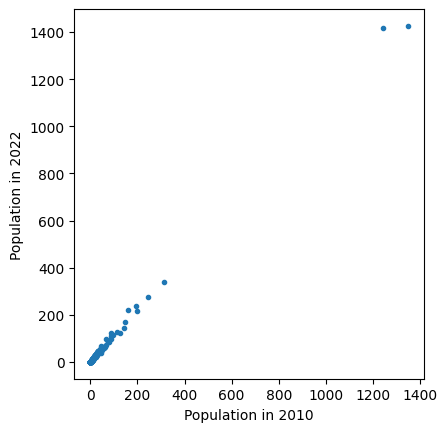

In [20]:
figure, axes = plt.subplots()
axes.plot(pop.pop2010, pop.pop2022, '.')
axes.set_aspect('equal')
axes.set_xlabel('Population in 2010')
axes.set_ylabel('Population in 2022')
pass

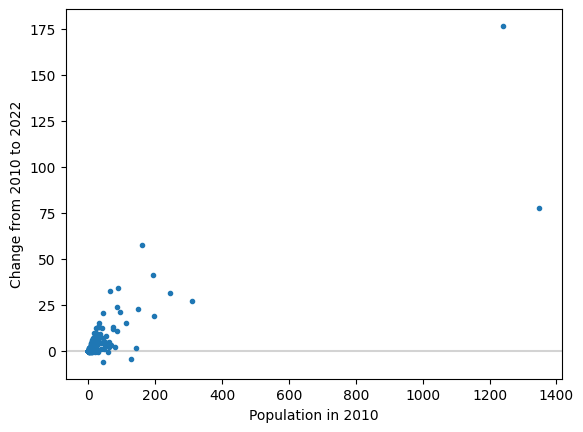

In [21]:
figure, axes = plt.subplots()
axes.axhline(0, color="lightgrey")
axes.plot(pop.pop2010, pop.difference, '.')
axes.set_xlabel('Population in 2010')
axes.set_ylabel('Change from 2010 to 2022')
pass

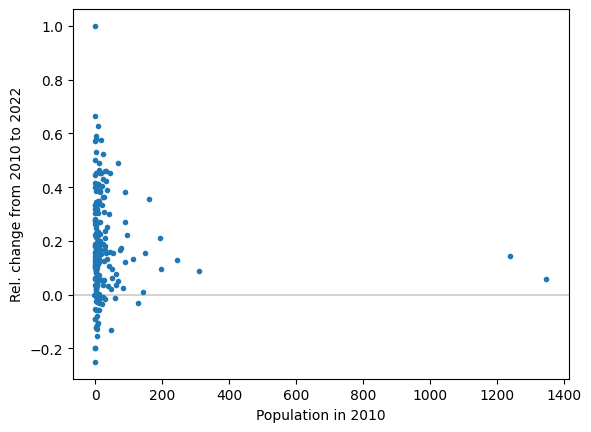

In [22]:
figure, axes = plt.subplots()
axes.axhline(0, color="lightgrey")
axes.plot(pop.pop2010, pop.relDifference, '.')
axes.set_xlabel('Population in 2010')
axes.set_ylabel('Rel. change from 2010 to 2022')
pass

In [23]:
pop.sort_values('relDifference').head(10)

Year,pop2010,pop2022,difference,relDifference
Region,,,,
Saint Martin (French part),0.04,0.03,-0.01,-0.250000
American Samoa,0.05,0.04,-0.01,-0.200000
Marshall Islands,0.05,0.04,-0.01,-0.200000
Bosnia and Herzegovina,3.81,3.23,-0.58,-0.152231
Ukraine,45.68,39.70,-5.98,-0.130911
Puerto Rico,3.72,3.25,-0.47,-0.126344
Lithuania,3.14,2.75,-0.39,-0.124204
Latvia,2.10,1.85,-0.25,-0.119048
Republic of Moldova,3.68,3.27,-0.41,-0.111413


In [24]:
pop.sort_values('relDifference', ascending=False).head(10)

Year,pop2010,pop2022,difference,relDifference
Region,,,,
Anguilla,0.01,0.02,0.01,1.000000
Turks and Caicos Islands,0.03,0.05,0.02,0.666667
Jordan,6.93,11.29,4.36,0.629149
Oman,2.88,4.58,1.70,0.590278
Qatar,1.71,2.70,0.99,0.578947
Niger,16.65,26.21,9.56,0.574174
Mayotte,0.21,0.33,0.12,0.571429
Equatorial Guinea,1.09,1.67,0.58,0.532110
Angola,23.36,35.59,12.23,0.523545


In [25]:
neighbor_countries = ['Slovakia', 'Ukraine', 'Poland', 'Czechia', 'Austria', 'Hungary'] 
neighbors = pop.loc[neighbor_countries, : ]
display(neighbors)

Year,pop2010,pop2022,difference,relDifference
Region,,,,
Slovakia,5.40,5.64,0.24,0.044444
Ukraine,45.68,39.70,-5.98,-0.130911
Poland,38.60,39.86,1.26,0.032642
Czechia,10.46,10.49,0.03,0.002868
Austria,8.36,8.94,0.58,0.069378
Hungary,9.99,9.97,-0.02,-0.002002


## Summary and outlook
* We will work mostly with tabular data.
* We will store them in `DataFrame` from Pandas library.
* This is more convenient and more efficient than regular Python lists.
* We have seen several functions for basic manipulation:
    * `iloc[]`, `loc[]`, `query`, `head`, `set_index`, `reset_index`, `rename`, `pivot`, `copy`, `sort_values`, operations and functions on `Series`.
* Next lecture will be focused on examples of different chart types.
* More Pandas later.